# Prueba de integración del proyecto Sudoku

Este notebook prueba el pipeline completo antes de crear `main.py` y `main_streamlit.py`.

```text
imagen
→ YOLO
→ corrección del tablero
→ 81 celdas
→ clasificación 0–9
→ validación
→ CNN de 19 canales
→ MRV + backtracking
→ solución
```

El notebook debe guardarse dentro de la carpeta:

```text
DL_proyecto/app/
```

Los modelos esperados son:

```text
app/models/
├── best.pt
├── best_class_0_9.keras
└── best_juego.keras
```

Arquitecturas esperadas:

- `best_class_0_9.keras`: entrada `(28, 28, 1)` y salida de 10 clases.
- `best_juego.keras`: entrada `(9, 9, 19)` y salida `(9, 9, 9)`.


## 1. Importar librerías

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from ultralytics import YOLO

## 2. Configuración

In [2]:
RUTA_YOLO = "models/best.pt"
RUTA_CLASS = "models/best_class_0_9.keras"
RUTA_JUEGO = "models/best_juego.keras"

RUTA_IMAGEN = (
    "../modelo_yolo/img_proc/images/test/"
    "sudoku_168_jpg.rf.pfhTWZY1G9sbBr6PPDKz.jpg"
)

MAX_NODOS = 100000

## 3. Cargar y comprobar los modelos

Esta comprobación evita continuar accidentalmente con los modelos antiguos.

In [3]:
modelo_yolo = YOLO(RUTA_YOLO)
modelo_class = keras.models.load_model(RUTA_CLASS)
modelo_juego = keras.models.load_model(RUTA_JUEGO)

print("Modelo class")
print("Entrada:", modelo_class.input_shape)
print("Salida:", modelo_class.output_shape)

print("\nModelo juego")
print("Entrada:", modelo_juego.input_shape)
print("Salida:", modelo_juego.output_shape)

Modelo class
Entrada: (None, 28, 28, 1)
Salida: (None, 10)

Modelo juego
Entrada: (None, 9, 9, 19)
Salida: (None, 9, 9, 9)


In [4]:
if tuple(modelo_class.input_shape[1:]) != (28, 28, 1):
    raise ValueError(
        "best_class.keras no es el modelo nuevo. "
        "Debe recibir imágenes de 28 × 28 × 1."
    )

if modelo_class.output_shape[-1] != 10:
    raise ValueError(
        "best_class.keras no tiene 10 clases. "
        "Debe clasificar 0–9."
    )

if tuple(modelo_juego.input_shape[1:]) != (9, 9, 19):
    raise ValueError(
        "best_juego.keras no es la CNN nueva. "
        "Debe recibir una entrada de 9 × 9 × 19."
    )

if tuple(modelo_juego.output_shape[1:]) != (9, 9, 9):
    raise ValueError(
        "La salida de best_juego.keras no es la esperada."
    )

print("Modelos correctos.")

Modelos correctos.


## 4. Cargar la imagen de prueba

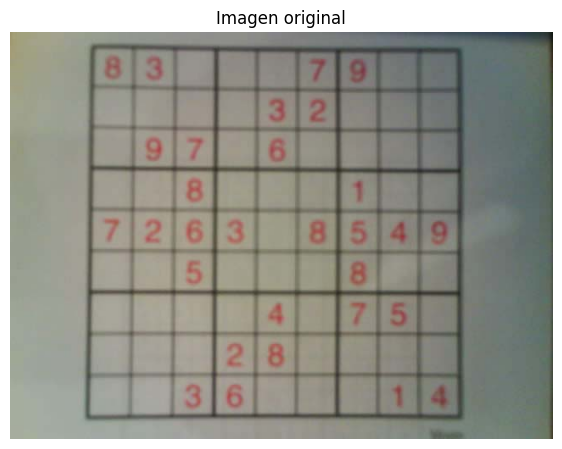

In [5]:
imagen = cv2.imread(RUTA_IMAGEN)

if imagen is None:
    raise ValueError(
        "No se ha podido cargar la imagen. "
        "Revisa RUTA_IMAGEN."
    )

plt.figure(figsize=(7, 7))
plt.imshow(
    cv2.cvtColor(
        imagen,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Imagen original")
plt.axis("off")
plt.show()

## 5. Detectar y corregir el tablero

In [6]:
def agrupar(posiciones, distancia=8):

    posiciones = sorted(posiciones)
    grupos = []

    for posicion in posiciones:

        if not grupos:
            grupos.append([posicion])

        elif posicion - np.mean(grupos[-1]) <= distancia:
            grupos[-1].append(posicion)

        else:
            grupos.append([posicion])

    return [
        int(np.mean(grupo))
        for grupo in grupos
    ]


def procesar_sudoku(imagen, modelo):

    resultado = modelo(
        imagen,
        verbose=False
    )[0]

    if len(resultado.boxes) == 0:
        raise ValueError(
            "No se ha detectado el Sudoku."
        )

    indice = int(
        resultado.boxes.conf.argmax().item()
    )

    x1, y1, x2, y2 = (
        resultado.boxes.xyxy[indice]
        .cpu()
        .numpy()
        .astype(int)
    )

    tablero = imagen[y1:y2, x1:x2]

    if tablero.size == 0:
        raise ValueError(
            "El recorte del tablero está vacío."
        )

    gris = cv2.cvtColor(
        tablero,
        cv2.COLOR_BGR2GRAY
    )

    gris = cv2.GaussianBlur(
        gris,
        (5, 5),
        0
    )

    binaria = cv2.adaptiveThreshold(
        gris,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        2
    )

    lineas = cv2.HoughLinesP(
        binaria,
        1,
        np.pi / 180,
        80,
        minLineLength=80,
        maxLineGap=15
    )

    if lineas is None:
        raise ValueError(
            "No se ha detectado la cuadrícula."
        )

    horizontales = []
    verticales = []

    for linea in lineas:

        x1, y1, x2, y2 = linea[0]

        if abs(x2 - x1) > abs(y2 - y1):
            horizontales.append(
                int((y1 + y2) / 2)
            )

        else:
            verticales.append(
                int((x1 + x2) / 2)
            )

    horizontales = agrupar(horizontales)
    verticales = agrupar(verticales)

    if len(horizontales) < 2 or len(verticales) < 2:
        raise ValueError(
            "No se han detectado los bordes."
        )

    origen = np.float32([
        [verticales[0], horizontales[0]],
        [verticales[-1], horizontales[0]],
        [verticales[-1], horizontales[-1]],
        [verticales[0], horizontales[-1]]
    ])

    destino = np.float32([
        [0, 0],
        [449, 0],
        [449, 449],
        [0, 449]
    ])

    matriz = cv2.getPerspectiveTransform(
        origen,
        destino
    )

    tablero = cv2.warpPerspective(
        tablero,
        matriz,
        (450, 450)
    )

    celdas = []

    for fila in range(9):
        for columna in range(9):

            celda = tablero[
                fila * 50:(fila + 1) * 50,
                columna * 50:(columna + 1) * 50
            ]

            celdas.append(celda)

    return tablero, celdas

Tablero: (450, 450, 3)
Número de celdas: 81


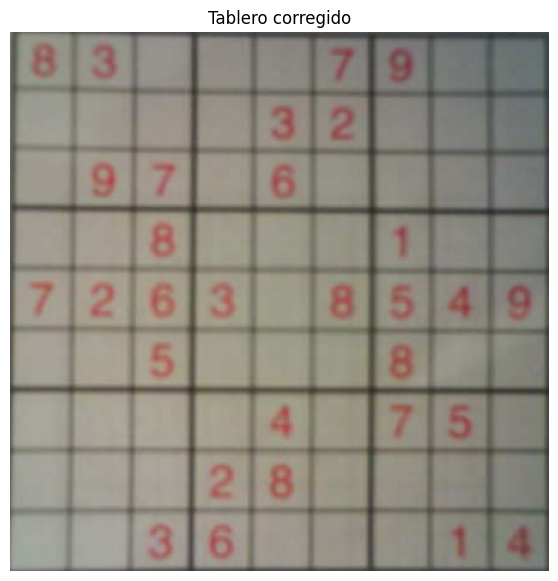

In [7]:
tablero, celdas = procesar_sudoku(
    imagen,
    modelo_yolo
)

print("Tablero:", tablero.shape)
print("Número de celdas:", len(celdas))

plt.figure(figsize=(7, 7))
plt.imshow(
    cv2.cvtColor(
        tablero,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Tablero corregido")
plt.axis("off")
plt.show()

## 6. Visualizar las 81 celdas

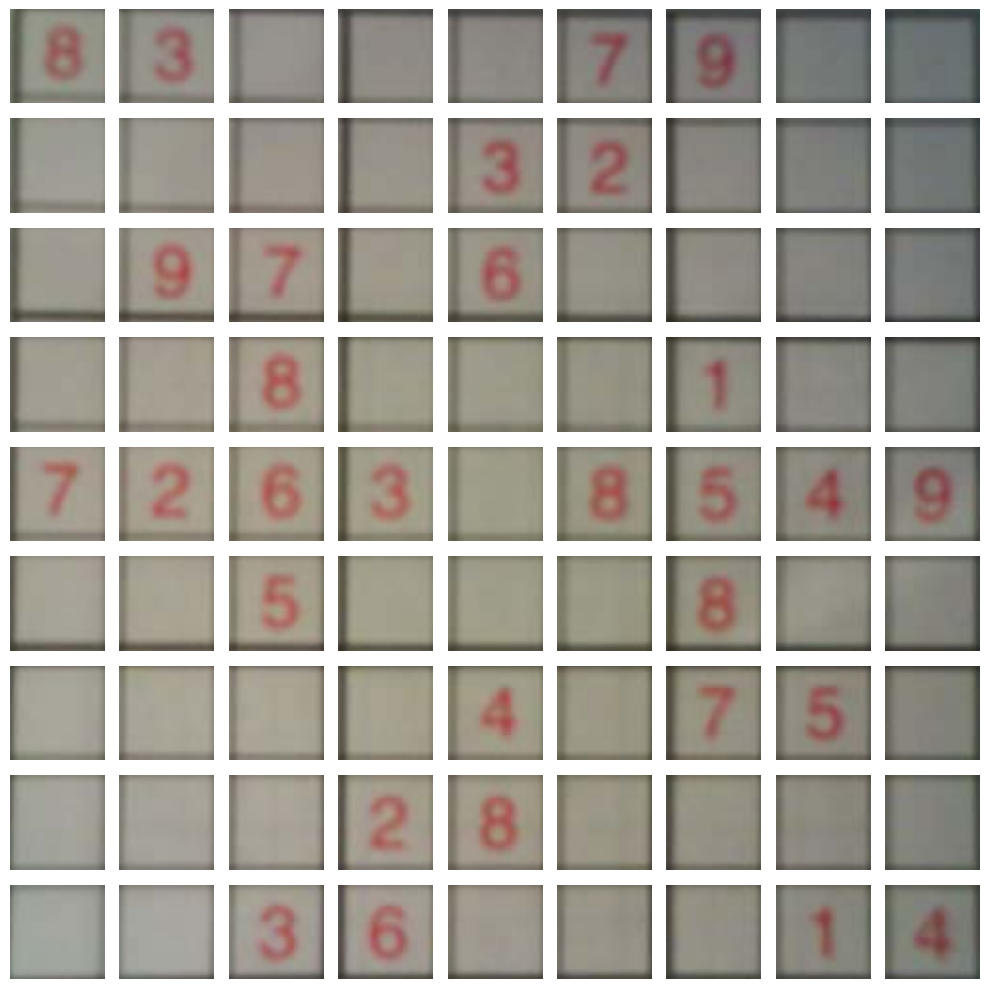

In [8]:
fig, axes = plt.subplots(
    9,
    9,
    figsize=(10, 10)
)

for i, celda in enumerate(celdas):

    fila = i // 9
    columna = i % 9

    axes[fila, columna].imshow(
        cv2.cvtColor(
            celda,
            cv2.COLOR_BGR2RGB
        )
    )

    axes[fila, columna].axis("off")

plt.tight_layout()
plt.show()

## 7. Preparar y clasificar las celdas

Antes de consultar la CNN, OpenCV comprueba si la celda contiene realmente un dígito.

Se descartan:

- componentes que tocan los bordes;
- líneas demasiado finas o alargadas;
- componentes con un área demasiado pequeña.

Si no queda ningún componente válido, la celda se marca directamente como `0`.

In [9]:
def preparar_celda(
    celda,
    margen=5,
    area_minima=80
):

    if len(celda.shape) == 3:
        celda = cv2.cvtColor(
            celda,
            cv2.COLOR_BGR2GRAY
        )

    celda = celda[
        margen:-margen,
        margen:-margen
    ]

    celda = cv2.GaussianBlur(
        celda,
        (3, 3),
        0
    )

    _, binaria = cv2.threshold(
        celda,
        0,
        255,
        cv2.THRESH_BINARY_INV
        + cv2.THRESH_OTSU
    )

    cantidad, etiquetas, estadisticas, _ = (
        cv2.connectedComponentsWithStats(
            binaria,
            connectivity=8
        )
    )

    alto_imagen, ancho_imagen = (
        binaria.shape
    )

    componentes_validos = []

    for indice in range(1, cantidad):

        x, y, ancho, alto, area = (
            estadisticas[indice]
        )

        toca_borde = (
            x <= 1
            or y <= 1
            or x + ancho >= ancho_imagen - 1
            or y + alto >= alto_imagen - 1
        )

        proporcion = (
            ancho / alto
            if alto > 0
            else 0
        )

        if toca_borde:
            continue

        if area < area_minima:
            continue

        if ancho < 3 or alto < 10:
            continue

        if proporcion < 0.12 or proporcion > 1.5:
            continue

        componentes_validos.append(
            (
                area,
                indice,
                x,
                y,
                ancho,
                alto
            )
        )

    if len(componentes_validos) == 0:

        return (
            np.zeros(
                (28, 28),
                dtype=np.uint8
            ),
            False
        )

    _, indice, x, y, ancho, alto = max(
        componentes_validos,
        key=lambda componente: componente[0]
    )

    componente = np.zeros_like(
        binaria
    )

    componente[
        etiquetas == indice
    ] = 255

    contenido = componente[
        y:y + alto,
        x:x + ancho
    ]

    escala = 20 / max(
        ancho,
        alto
    )

    nuevo_ancho = max(
        1,
        int(round(ancho * escala))
    )

    nuevo_alto = max(
        1,
        int(round(alto * escala))
    )

    contenido = cv2.resize(
        contenido,
        (
            nuevo_ancho,
            nuevo_alto
        ),
        interpolation=cv2.INTER_AREA
    )

    imagen = np.zeros(
        (28, 28),
        dtype=np.uint8
    )

    inicio_x = (
        28 - nuevo_ancho
    ) // 2

    inicio_y = (
        28 - nuevo_alto
    ) // 2

    imagen[
        inicio_y:inicio_y + nuevo_alto,
        inicio_x:inicio_x + nuevo_ancho
    ] = contenido

    momentos = cv2.moments(
        imagen
    )

    if momentos["m00"] != 0:

        centro_x = (
            momentos["m10"]
            / momentos["m00"]
        )

        centro_y = (
            momentos["m01"]
            / momentos["m00"]
        )

        mover_x = int(
            round(14 - centro_x)
        )

        mover_y = int(
            round(14 - centro_y)
        )

        matriz = np.float32([
            [1, 0, mover_x],
            [0, 1, mover_y]
        ])

        imagen = cv2.warpAffine(
            imagen,
            matriz,
            (28, 28)
        )

    return imagen, True


def clasificar_celdas(celdas, modelo):

    celdas_preparadas = []
    contenido_detectado = []

    for celda in celdas:

        celda_preparada, tiene_contenido = (
            preparar_celda(
                celda
            )
        )

        celdas_preparadas.append(
            celda_preparada
        )

        contenido_detectado.append(
            tiene_contenido
        )

    celdas_preparadas = np.array(
        celdas_preparadas
    )

    contenido_detectado = np.array(
        contenido_detectado
    )

    entrada = (
        celdas_preparadas.astype(
            "float32"
        )
        / 255.0
    ).reshape(
        -1,
        28,
        28,
        1
    )

    probabilidades = modelo.predict(
        entrada,
        verbose=0
    )

    numeros = np.argmax(
        probabilidades,
        axis=1
    )

    confianzas = np.max(
        probabilidades,
        axis=1
    )

    numeros[
        ~contenido_detectado
    ] = 0

    confianzas[
        ~contenido_detectado
    ] = 1.0

    puzzle = numeros.reshape(
        9,
        9
    )

    return (
        celdas_preparadas,
        puzzle,
        confianzas.reshape(9, 9),
        contenido_detectado.reshape(9, 9)
    )

In [10]:
(
    celdas_preparadas,
    puzzle,
    confianzas,
    contenido_detectado
) = clasificar_celdas(
    celdas,
    modelo_class
)

print("Puzzle reconocido:")
print(puzzle)

print(
    "\nCeldas con número:",
    int(contenido_detectado.sum())
)

print(
    "Celdas vacías:",
    int(81 - contenido_detectado.sum())
)

print(
    "Confianza media:",
    f"{confianzas.mean():.2%}"
)

Puzzle reconocido:
[[8 3 0 0 0 7 9 0 0]
 [0 0 0 0 3 2 0 0 0]
 [0 9 7 0 6 0 0 0 0]
 [0 0 8 0 0 0 1 0 0]
 [7 2 6 3 0 8 5 4 9]
 [0 0 5 0 0 0 8 0 0]
 [0 0 0 0 4 0 7 5 0]
 [0 0 0 2 8 0 0 0 0]
 [0 0 3 6 0 0 0 1 4]]

Celdas con número: 30
Celdas vacías: 51
Confianza media: 100.00%


In [11]:
print(
    "Máscara de contenido "
    "(1 = número, 0 = vacía):"
)

print(
    contenido_detectado.astype(int)
)

Máscara de contenido (1 = número, 0 = vacía):
[[1 1 0 0 0 1 1 0 0]
 [0 0 0 0 1 1 0 0 0]
 [0 1 1 0 1 0 0 0 0]
 [0 0 1 0 0 0 1 0 0]
 [1 1 1 1 0 1 1 1 1]
 [0 0 1 0 0 0 1 0 0]
 [0 0 0 0 1 0 1 1 0]
 [0 0 0 1 1 0 0 0 0]
 [0 0 1 1 0 0 0 1 1]]


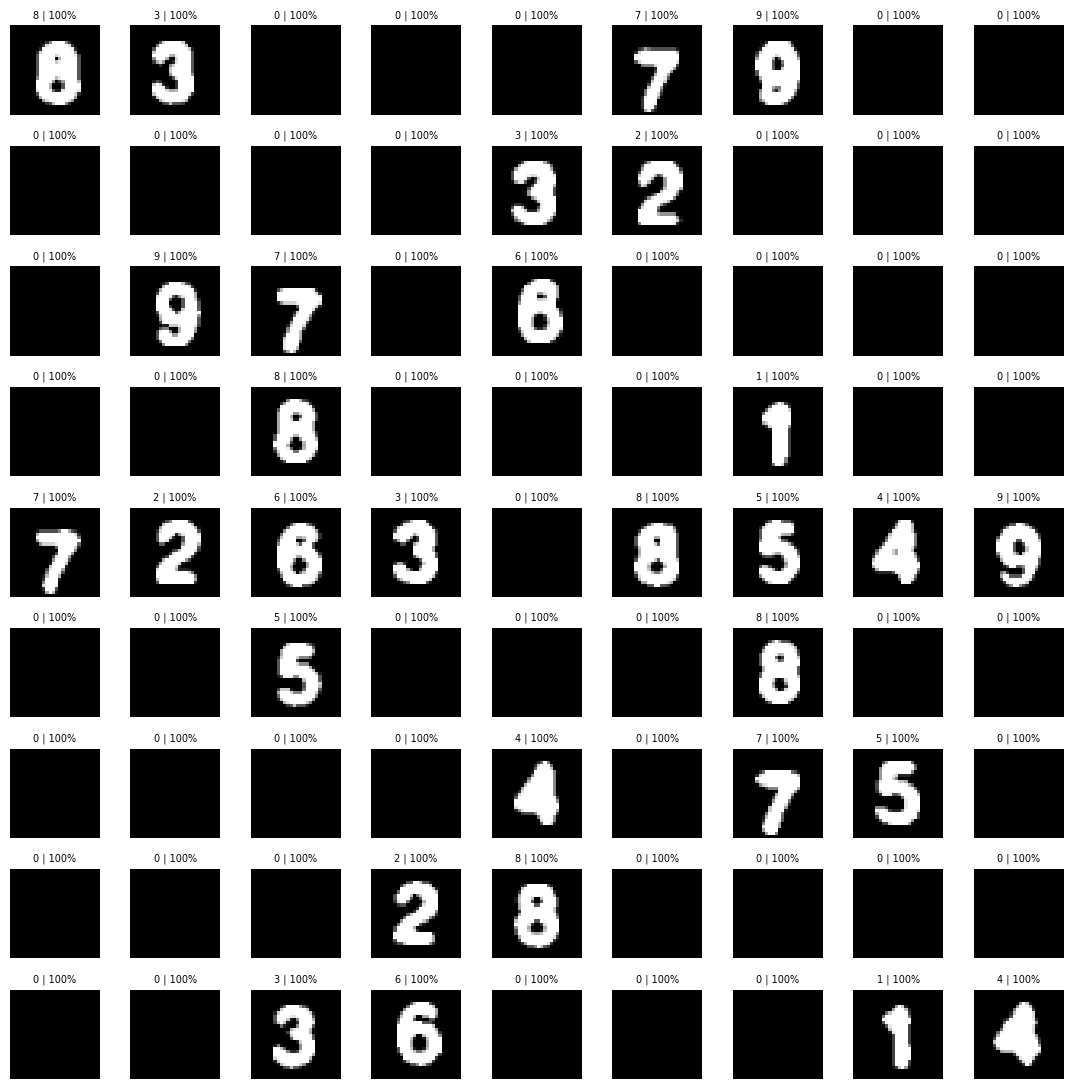

In [12]:
fig, axes = plt.subplots(
    9,
    9,
    figsize=(11, 11)
)

for i, celda in enumerate(celdas_preparadas):

    fila = i // 9
    columna = i % 9

    numero = puzzle[
        fila,
        columna
    ]

    confianza = confianzas[
        fila,
        columna
    ]

    axes[fila, columna].imshow(
        celda,
        cmap="gray"
    )

    axes[fila, columna].set_title(
        f"{numero} | {confianza:.0%}",
        fontsize=7
    )

    axes[fila, columna].axis("off")

plt.tight_layout()
plt.show()

## 8. Corregir manualmente el puzzle

Esta celda permite corregir errores antes de probar el resolvedor.

Ejemplo:

```python
puzzle_corregido[0, 0] = 5
```

No modifiques una celda si el reconocimiento es correcto.

In [13]:
puzzle_corregido = puzzle.copy()

# Ejemplos de corrección:
# puzzle_corregido[0, 0] = 5
# puzzle_corregido[2, 4] = 0

print(puzzle_corregido)

[[8 3 0 0 0 7 9 0 0]
 [0 0 0 0 3 2 0 0 0]
 [0 9 7 0 6 0 0 0 0]
 [0 0 8 0 0 0 1 0 0]
 [7 2 6 3 0 8 5 4 9]
 [0 0 5 0 0 0 8 0 0]
 [0 0 0 0 4 0 7 5 0]
 [0 0 0 2 8 0 0 0 0]
 [0 0 3 6 0 0 0 1 4]]


## 9. Validar las pistas

In [14]:
def puzzle_parcial_valido(tablero):

    for i in range(9):

        fila = tablero[i, :]
        fila = fila[fila != 0]

        if len(fila) != len(set(fila)):
            return False

        columna = tablero[:, i]
        columna = columna[columna != 0]

        if len(columna) != len(set(columna)):
            return False

    for fila in range(0, 9, 3):
        for columna in range(0, 9, 3):

            bloque = tablero[
                fila:fila + 3,
                columna:columna + 3
            ].flatten()

            bloque = bloque[
                bloque != 0
            ]

            if len(bloque) != len(set(bloque)):
                return False

    return True


if puzzle_parcial_valido(
    puzzle_corregido
):
    print("Puzzle inicial válido.")
else:
    print(
        "Puzzle inválido. "
        "Corrige los números reconocidos antes de resolver."
    )

Puzzle inicial válido.


## 10. Preparar la entrada de 19 canales

La CNN del juego recibe:

```text
10 canales del tablero
+
9 canales de candidatos legales
=
19 canales
```

In [15]:
def crear_candidatos(tableros):

    one_hot = keras.utils.to_categorical(
        tableros,
        num_classes=10
    ).astype("float32")

    numeros = one_hot[..., 1:]

    usados_fila = numeros.max(
        axis=2
    )[:, :, None, :]

    usados_columna = numeros.max(
        axis=1
    )[:, None, :, :]

    bloques = numeros.reshape(
        -1,
        3,
        3,
        3,
        3,
        9
    )

    usados_bloque = bloques.max(
        axis=(2, 4)
    )

    usados_bloque = np.repeat(
        np.repeat(
            usados_bloque,
            3,
            axis=1
        ),
        3,
        axis=2
    )

    candidatos = 1 - np.maximum.reduce([
        np.broadcast_to(
            usados_fila,
            numeros.shape
        ),
        np.broadcast_to(
            usados_columna,
            numeros.shape
        ),
        usados_bloque
    ])

    candidatos[tableros != 0] = 0

    return candidatos.astype(
        "float32"
    )


def crear_entrada_cnn(tableros):

    one_hot = keras.utils.to_categorical(
        tableros,
        num_classes=10
    ).astype("float32")

    candidatos = crear_candidatos(
        tableros
    )

    return np.concatenate(
        [one_hot, candidatos],
        axis=-1
    )

## 11. Resolver mediante MRV y backtracking

In [16]:
def candidatos_validos(
    tablero,
    fila,
    columna
):

    usados = set(
        tablero[fila, :]
    )

    usados.update(
        tablero[:, columna]
    )

    fila_bloque = (
        fila // 3
    ) * 3

    columna_bloque = (
        columna // 3
    ) * 3

    usados.update(
        tablero[
            fila_bloque:fila_bloque + 3,
            columna_bloque:columna_bloque + 3
        ].flatten()
    )

    return [
        numero
        for numero in range(1, 10)
        if numero not in usados
    ]


def seleccionar_celda_mrv(tablero):

    mejor_celda = None
    mejores_candidatos = None

    for fila in range(9):
        for columna in range(9):

            if tablero[
                fila,
                columna
            ] != 0:
                continue

            candidatos = candidatos_validos(
                tablero,
                fila,
                columna
            )

            if len(candidatos) == 0:
                return fila, columna, []

            if (
                mejores_candidatos is None
                or len(candidatos)
                < len(mejores_candidatos)
            ):

                mejor_celda = (
                    fila,
                    columna
                )

                mejores_candidatos = candidatos

            if len(mejores_candidatos) == 1:
                break

        if (
            mejores_candidatos is not None
            and len(mejores_candidatos) == 1
        ):
            break

    if mejor_celda is None:
        return None

    fila, columna = mejor_celda

    return (
        fila,
        columna,
        mejores_candidatos
    )


def sudoku_valido(tablero):

    numeros = set(
        range(1, 10)
    )

    for i in range(9):

        if set(tablero[i, :]) != numeros:
            return False

        if set(tablero[:, i]) != numeros:
            return False

    for fila in range(0, 9, 3):
        for columna in range(0, 9, 3):

            bloque = tablero[
                fila:fila + 3,
                columna:columna + 3
            ]

            if set(
                bloque.flatten()
            ) != numeros:
                return False

    return True


def predecir_probabilidades(
    tablero,
    modelo
):

    entrada = crear_entrada_cnn(
        tablero.reshape(1, 9, 9)
    )

    return modelo(
        entrada,
        training=False
    ).numpy()[0]


def resolver_backtracking(
    puzzle,
    modelo,
    max_nodos=100000
):

    tablero = np.array(
        puzzle,
        dtype=int
    ).reshape(9, 9).copy()

    estadisticas = {
        "nodos": 0,
        "retrocesos": 0
    }

    if not puzzle_parcial_valido(
        tablero
    ):
        return None, estadisticas

    def buscar():

        if estadisticas["nodos"] >= max_nodos:
            return False

        estadisticas["nodos"] += 1

        if 0 not in tablero:
            return sudoku_valido(
                tablero
            )

        seleccion = seleccionar_celda_mrv(
            tablero
        )

        if seleccion is None:
            return False

        fila, columna, candidatos = seleccion

        if len(candidatos) == 0:

            estadisticas[
                "retrocesos"
            ] += 1

            return False

        probabilidades = predecir_probabilidades(
            tablero,
            modelo
        )

        candidatos = sorted(
            candidatos,
            key=lambda numero: probabilidades[
                fila,
                columna,
                numero - 1
            ],
            reverse=True
        )

        for numero in candidatos:

            tablero[
                fila,
                columna
            ] = numero

            if buscar():
                return True

            tablero[
                fila,
                columna
            ] = 0

            estadisticas[
                "retrocesos"
            ] += 1

        return False

    resuelto = buscar()

    if resuelto:
        return tablero.copy(), estadisticas

    return None, estadisticas

In [17]:
if not puzzle_parcial_valido(
    puzzle_corregido
):

    print(
        "No se puede resolver: "
        "el puzzle inicial contiene contradicciones."
    )

    solucion = None
    estadisticas = None

else:

    solucion, estadisticas = resolver_backtracking(
        puzzle_corregido,
        modelo_juego,
        max_nodos=MAX_NODOS
    )

    if solucion is None:

        print(
            "No se ha encontrado una solución."
        )

    else:

        print("Sudoku resuelto:")
        print(solucion)

        print(
            "\nSudoku válido:",
            sudoku_valido(solucion)
        )

        print(
            "Nodos:",
            estadisticas["nodos"]
        )

        print(
            "Retrocesos:",
            estadisticas["retrocesos"]
        )

Sudoku resuelto:
[[8 3 2 4 5 7 9 6 1]
 [6 5 1 9 3 2 4 8 7]
 [4 9 7 8 6 1 3 2 5]
 [3 4 8 5 9 6 1 7 2]
 [7 2 6 3 1 8 5 4 9]
 [9 1 5 7 2 4 8 3 6]
 [2 6 9 1 4 3 7 5 8]
 [1 7 4 2 8 5 6 9 3]
 [5 8 3 6 7 9 2 1 4]]

Sudoku válido: True
Nodos: 52
Retrocesos: 0


## 12. Mostrar la solución

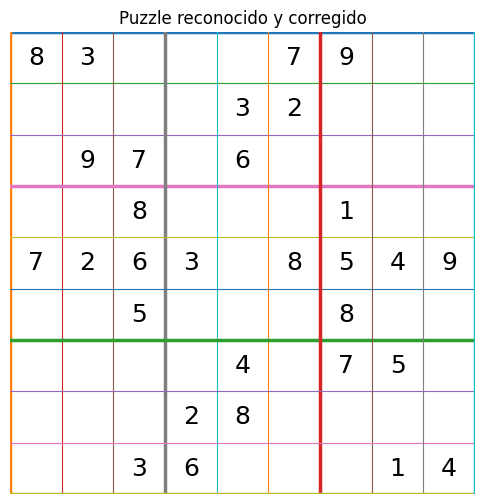

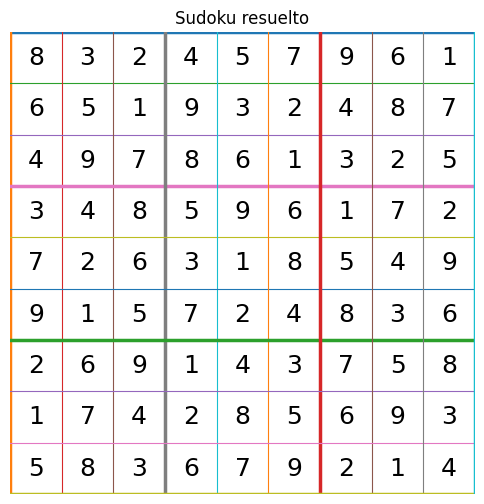

In [18]:
def mostrar_sudoku(tablero, titulo):

    fig, ax = plt.subplots(
        figsize=(6, 6)
    )

    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)
    ax.invert_yaxis()

    for i in range(10):

        grosor = (
            2.5
            if i % 3 == 0
            else 0.8
        )

        ax.plot(
            [0, 9],
            [i, i],
            linewidth=grosor
        )

        ax.plot(
            [i, i],
            [0, 9],
            linewidth=grosor
        )

    for fila in range(9):
        for columna in range(9):

            numero = tablero[
                fila,
                columna
            ]

            if numero != 0:

                ax.text(
                    columna + 0.5,
                    fila + 0.5,
                    str(numero),
                    ha="center",
                    va="center",
                    fontsize=18
                )

    ax.set_title(titulo)
    ax.axis("off")
    plt.show()


mostrar_sudoku(
    puzzle_corregido,
    "Puzzle reconocido y corregido"
)

if solucion is not None:

    mostrar_sudoku(
        solucion,
        "Sudoku resuelto"
    )

# Criterio para superar la prueba

La integración queda validada cuando:

- YOLO detecta correctamente el tablero.
- La perspectiva produce 81 celdas bien recortadas.
- OpenCV separa correctamente celdas vacías y ocupadas.
- El clasificador reconoce los números impresos.
- El puzzle inicial es válido.
- El resolvedor devuelve una solución válida.
- El número de nodos y retrocesos es razonable.

Después de superar esta prueba se crearán:

1. `procesar_sudoku.py`
2. `clasificar_celdas.py`
3. `resolver_sudoku.py`
4. `main.py`
5. `main_streamlit.py`
